In [1]:
import os, io, sys, platform, warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests

import torch, torchvision
from torchvision import transforms

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("Platform:", platform.platform())

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị:", device)

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.9.0+cpu
TorchVision: 0.24.0+cpu
Platform: Windows-11-10.0.26200-SP0
Thiết bị: cpu


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def load_image(path_or_url, to_rgb=True):
    try:
        if str(path_or_url).startswith(("http://","https://")):
            resp = requests.get(path_or_url, timeout=15)
            resp.raise_for_status()
            img = Image.open(io.BytesIO(resp.content))
        else:
            img = Image.open(path_or_url)
    except Exception as e:
        print("Không thể tải ảnh:", e)
        raise
    if to_rgb and img.mode != "RGB":
        img = img.convert("RGB")
    return img

def show_image(img, title=None):
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

def preprocess_imagenet(img_pil, size=224):
    tfm = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return tfm(img_pil).unsqueeze(0)

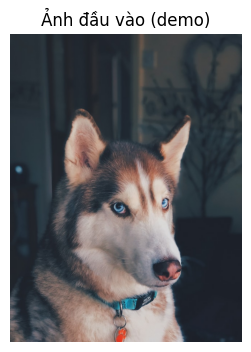

In [3]:
IMG_PATH = r"D:\năm 4\PythonSGU\BaiTap+BaiGiangML\BaiTap\img\dog_alaska.jpg"

img_source = IMG_PATH
img = load_image(img_source, to_rgb=True)
show_image(img, "Ảnh đầu vào (demo)")

# YOLO — Phát hiện đối tượng (one‑stage).

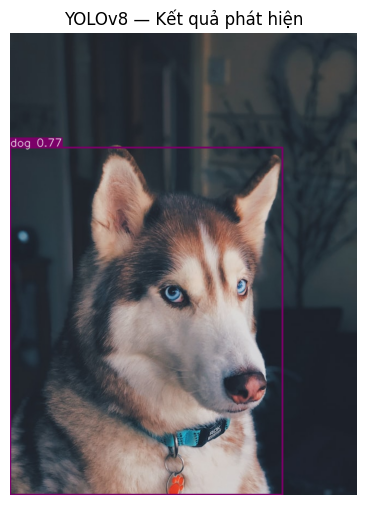

Các đối tượng phát hiện:
  - dog: conf=0.77


In [5]:
try:
    from ultralytics import YOLO
    have_ultralytics = True
except Exception as e:
    have_ultralytics = False
    print("Chưa có 'ultralytics'. Cài bằng: pip install -U ultralytics")

if have_ultralytics:
    try:
        yolo = YOLO('yolov8n.pt')  # tải lần đầu nếu chưa có
        results = yolo.predict(img, conf=0.25, verbose=False)
        res = results[0]
        annotated = res.plot()[:, :, ::-1]  # BGR->RGB
        plt.figure(figsize=(6,6))
        plt.imshow(annotated)
        plt.axis("off")
        plt.title("YOLOv8 — Kết quả phát hiện")
        plt.show()

        if res.boxes is not None and len(res.boxes) > 0:
            print("Các đối tượng phát hiện:")
            for b in res.boxes:
                cls_id = int(b.cls.item())
                conf  = float(b.conf.item())
                name  = res.names.get(cls_id, str(cls_id))
                print(f"  - {name}: conf={conf:.2f}")
        else:
            print("Không phát hiện được đối tượng nào với ngưỡng conf hiện tại.")
    except Exception as e:
        print("Không thể chạy YOLO:", e)
        print("Bạn có thể tải sẵn yolov8n.pt và thay đường dẫn local trong YOLO('path/to/yolov8n.pt').")
